Classical Libraries:
$$MSE = \frac{1}{mn}\sum_{i=0}^{m-1}\sum_{j=0}^{n-1}[I(i,j) - K(i,j)]^{2}$$

In [44]:
import math
from pandas import DataFrame as df
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.integrate import odeint, ode
from scipy.integrate import solve_ivp
import pdb # fortroubleshooting code
import seaborn as sns # statistical visualization 
from sklearn.ensemble import RandomForestClassifier # Macine Learning 
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

Quantum Libraries from IBM:

In [45]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_vector, plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

Print the qiskit version? (this question has been asked on IBM exam)

In [46]:
print(qiskit.version.get_version_info())

1.2.4


In [47]:
AerSimulator

qiskit_aer.backends.aer_simulator.AerSimulator

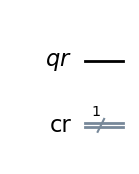

In [48]:
"""
OLDER FORMAT:
cr = ClassicalRegister(1,"cr")
qr = QuantumRegister(1,"qr")
qc = QuantumCircuit(1,"qc")
qc.draw('mpl')
"""
qr = QuantumRegister(1, "qr") # quantum register provides a storage unit which holds/records superpositions of states (qubits)
cr = ClassicalRegister(1, "cr") #a storage unit for classical bits (0s or 1s), acting like a simple array to hold/record discrete numerical values

qc = QuantumCircuit(qr, cr, name="qc") #attach registers to the circuit
qc.draw('mpl')

Pauli X Gate in Qiskit:
---------------------------

**Basic Qiskit Information:** <br>
* All qubits in Qiskit starts from the state |0> by default
* Qiskit uses little endian ordering system for both classical bit and quantum bit ordering. This means that for 3 qubits $q_{0}$, $q_{1}$, & $q_{2}$, the qiskit ordering is reversed as $q_{2}$, $q_{1}$, & $q_{0}$. Same if for classical bits as well. 

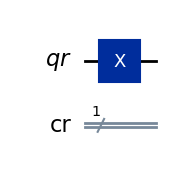

In [49]:
qr_x = QuantumRegister(1,"qr")
qc_x = QuantumCircuit(qr, cr, name="qc")
qc_x.x(qr_x[0])
# qc_x.save_statevector
#qc_x.save_unitary()
qc_x.draw('mpl')

In [50]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import transpile


Quantum State is: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
[0.+0.j 1.+0.j]


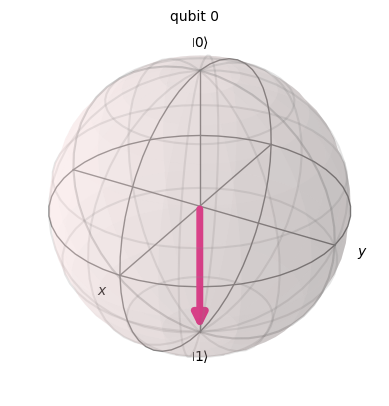

In [51]:
# qc_x is your QuantumCircuit
state = Statevector.from_instruction(qc_x) 
#takes a QuantumCircuit (or gate, or instruction) and mathematically simulates its action to produce the final statevector.
#It applies every gate in your circuit, step by step, using linear algebra, and returns the resulting quantum state.
state_rounded = np.round(state.data, 3)

print("\nQuantum State is:", state)
print(state_rounded)

plot_bloch_multivector(state)


Quantum State is: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


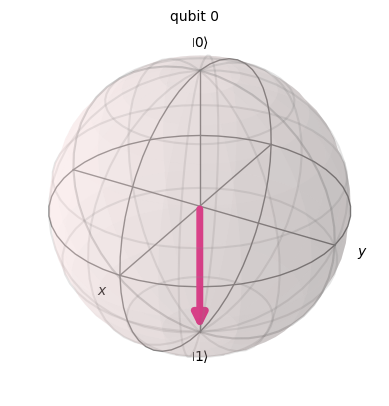

In [52]:
"""
If you really want to use AerSimulator: In newer Qiskit + qiskit-aer, AerSimulator does NOT give you a statevector by default.
You must explicitly save it in the circuit.
"""
# Make a copy so you don't modify qc_x in-place
qc_sim = qc_x.copy()
qc_sim.save_statevector()          # this is the crucial line

backend = AerSimulator(method='statevector') #Create a virtual quantum computer on my laptop that simulates quantum mechanics by storing the quantum state as a statevector.
qc_t = transpile(qc_sim, backend) #transpiler converts your high-level circuit into a form that a specific backend can run.
result = backend.run(qc_t).result()

state = result.get_statevector()   # now this works

print("\nQuantum State is:", state)
plot_bloch_multivector(state)

In [53]:
"""
OLDER FORMAT:
backend = Aer.get_backend('statevector_simulator')
result = execute(qc_x, backend). result().get_statevector(qc_x, decimals=3)

print("\n Quantum State is:", result)

plot_bloch_multivector(result)
"""
"""
Execute-> runs qc w/ statevector_simulator -> then we get the result -> from the result we get the statevector
for the given circuit. 
"""

'\nExecute-> runs qc w/ statevector_simulator -> then we get the result -> from the result we get the statevector\nfor the given circuit. \n'

In [54]:
#if you really want to use Aer

backend = Aer.get_backend('aer_simulator_unitary')

qc_u = qc_x.copy()
qc_u.save_unitary()        # 👈 mandatory

qc_t = transpile(qc_u, backend)

result = backend.run(qc_t).result()
unitary = result.get_unitary()

print(unitary)

Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


In [55]:
from qiskit.quantum_info import Operator

unitary = Operator(qc_x).data   # NumPy array
print(unitary)

[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


We can also add measurement:

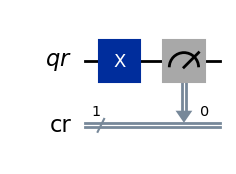

In [56]:
cr_x = ClassicalRegister(1, "cr")
qr_x = QuantumRegister(1,"qr")
qc_x = QuantumCircuit(qr, cr, name="qc")
qc_x.x(qr_x[0])
qc_x.measure(0,0)# one qbit going into a classical bit
qc_x.draw('mpl')

In [57]:
backend = Aer.get_backend('qasm_simulator') 
"""
#A qasm_simulator is a software tool that runs on a classical computer to emulate the execution of a quantum circuit 
#defined in the Quantum Assembly Language (QASM).
"""
qc_t = transpile(qc_x, backend) # transpile means translate Python source code into another higher-level language (ex. C++)
result = backend.run(qc_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)


Total Counts are: {'1': 1000}


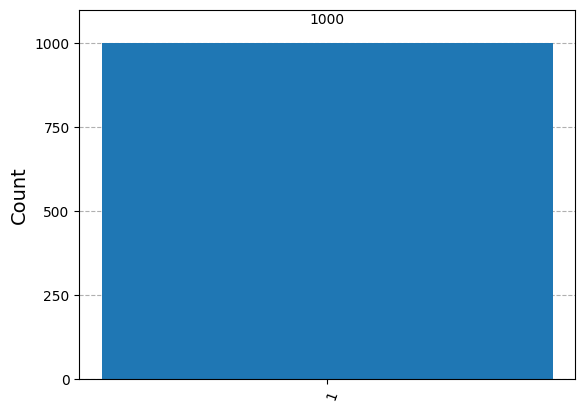

In [58]:
plot_histogram(counts)

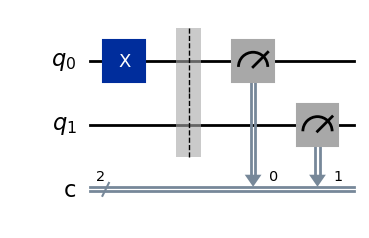

In [59]:
qc_x = QuantumCircuit(2,2,name="qc")
qc_x.x(0)
qc_x.barrier() 
#a synchronization tool in parallel computing, forcing threads/tasks to wait at a point until all others arrive 
#before proceeding, preventing data races and coordinating phases
qc_x.measure(0,0)
qc_x.measure(1,1)
#qc_x.measure([0,1],[0,1]) #<-- same thing 
#qc_x.measure_all() <-- will use measure not c
qc_x.draw('mpl')


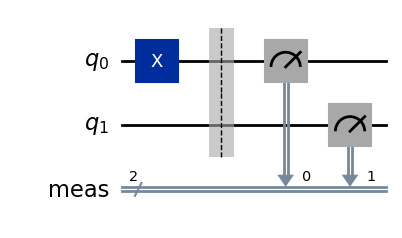

In [60]:
qc = QuantumCircuit(2,name="qc")
qc.x(0)
qc.measure_all() #applies circuit to all quantum 
qc.draw('mpl')

Pauli Y and Pauli Z Gates in Qiskit
------------------------------------

Pauli Y gate:

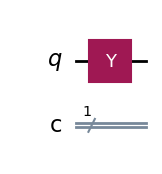

In [98]:
qc_y = QuantumCircuit(1, 1, name="qc")
qc_y.y(0)
qc_y.draw('mpl')


Quantum State is: Statevector([0.+0.j, 0.+1.j],
            dims=(2,))
[0.+0.j 0.+1.j]


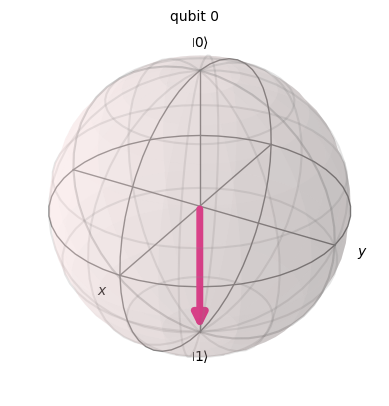

In [99]:
# qc_y is your QuantumCircuit
state_y = Statevector.from_instruction(qc_y) 
state_y_rounded = np.round(state_y.data, 3)

print("\nQuantum State is:", state_y)
print(state_y_rounded)

plot_bloch_multivector(state_y) #notice you won't be able to visualize i but instead only the state (in this case |1>)

In [63]:
unitary = Operator(qc_y).data   # NumPy array
print(unitary)

[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]


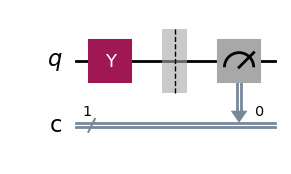

In [64]:
#cr_y = ClassicalRegister(1, "cr")
#qr_y = QuantumRegister(1,"qr")
qc_y = QuantumCircuit(1, 1, name="qc")
qc_y.y(0)
qc_y.barrier(0,0)
qc_y.measure(0,0)# one qbit going into a classical bit
qc_y.draw('mpl')


Total Counts are: {'1': 1000}


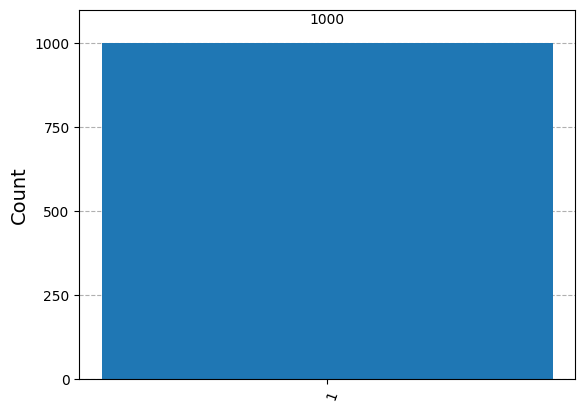

In [65]:
backend = Aer.get_backend('qasm_simulator') 
qc_t = transpile(qc_y, backend)
result = backend.run(qc_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

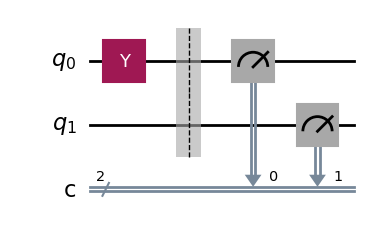

In [66]:
qc_y = QuantumCircuit(2,2,name="qc")
qc_y.y(0)
qc_y.barrier()
qc_y.measure(0,0)
qc_y.measure(1,1)
#qc_x.measure([0,1],[0,1]) #<-- same thing 
#qc_x.measure_all() <-- will use measure not c
qc_y.draw('mpl')

Pauli Z gate:

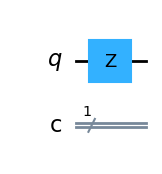

In [67]:
qc_z = QuantumCircuit(1, 1, name="qc")
#qc_z.x(0) # can add multiple qbit gates like this
qc_z.z(0)
qc_z.draw('mpl')


Quantum State is: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
[1.+0.j 0.+0.j]


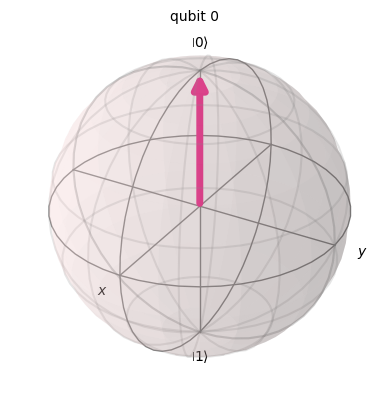

In [68]:
# qc_z is your QuantumCircuit
state_z = Statevector.from_instruction(qc_z) 
state_z_rounded = np.round(state_z.data, 3)

print("\nQuantum State is:", state_z)
print(state_z_rounded)

plot_bloch_multivector(state_z)

In [69]:
unitary = Operator(qc_z).data   # NumPy array
print(unitary)

[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


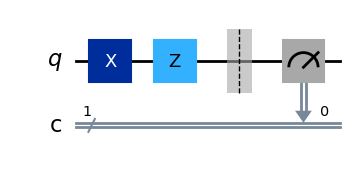

In [70]:
qc_z = QuantumCircuit(1, 1, name="qc")
qc_z.x(0)
qc_z.z(0)
qc_z.barrier(0,0)
qc_z.measure(0,0)# one qbit going into a classical bit
qc_z.draw('mpl')


Total Counts are: {'1': 1000}


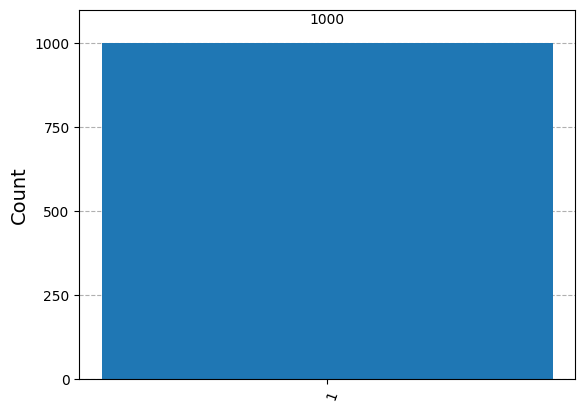

In [71]:
backend = Aer.get_backend('qasm_simulator') 

qc_t = transpile(qc_z, backend)
result = backend.run(qc_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

S, S Dagger, T & T Dagger Gates in Qiskit:
------------------------------------------

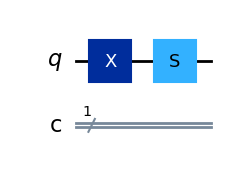

In [72]:
qc_s = QuantumCircuit(1,1,name="qc")
qc_s.x(0)
qc_s.s(0)
#qc_s.barrier(0,0)
#qc_s.measure(0,0)# one qbit going into a classical bit
qc_s.draw('mpl')


Quantum State is: Statevector([0.+0.j, 0.+1.j],
            dims=(2,))
[0.+0.j 0.+1.j]


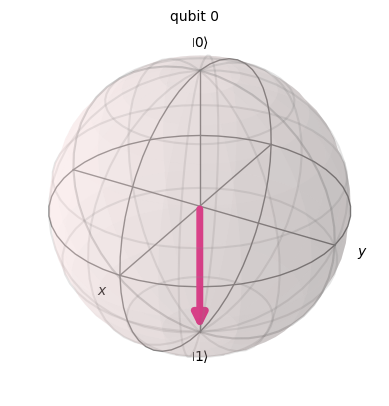

In [73]:
# qc_s is your QuantumCircuit
state_s = Statevector.from_instruction(qc_s) 
state_s_rounded = np.round(state_s.data, 3)

print("\nQuantum State is:", state_s)
print(state_s_rounded)

plot_bloch_multivector(state_s)

In [74]:
unitary_s = Operator(qc_s).data   # NumPy array
print(unitary_s)

[[0.+0.j 1.+0.j]
 [0.+1.j 0.+0.j]]



Total Counts are: {'1': 1000}


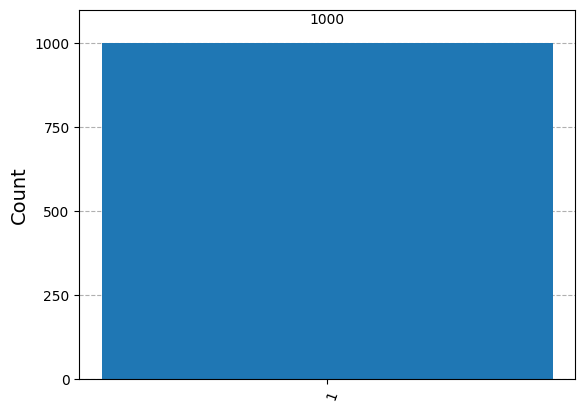

In [75]:
backend = Aer.get_backend('qasm_simulator')
qc_st = transpile(qc_s, backend)
results = backend.run(qc_s, shots = 1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)

plot_histogram(counts)

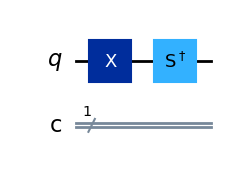

In [76]:
#S Dagger Gate
qc_sdg = QuantumCircuit(1,1,name="qc")
qc_sdg.x(0)
qc_sdg.sdg(0)
qc_sdg.draw('mpl')


Quantum State is: [0.+0.j 0.-1.j]


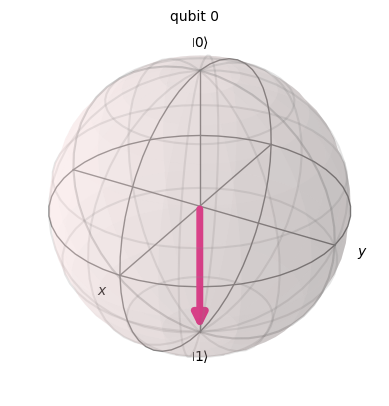

In [77]:
# qc_sdg is your QuantumCircuit
state_sdg = Statevector.from_instruction(qc_sdg) 
state_rounded_sdg = np.round(state_sdg.data, 3)

print("\nQuantum State is:", state_rounded_sdg)

plot_bloch_multivector(state_rounded_sdg)

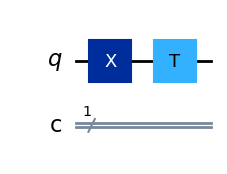

In [78]:
#T Gate
qc_T = QuantumCircuit(1,1, name = "qc")
qc_T.x(0) #|0> applied on T gate
qc_T.t(0) 
qc_T.draw('mpl')


Quantum State is: [0.   +0.j    0.707+0.707j]


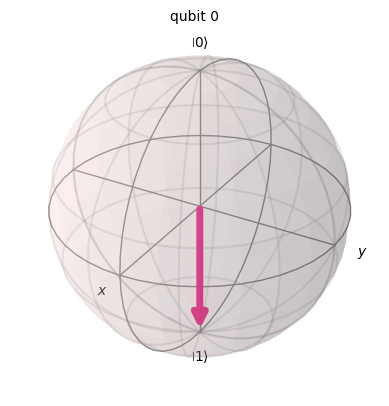

In [79]:
state_T = Statevector.from_instruction(qc_T)
state_rounded_T = np.round(state_T.data, 3)

print("\nQuantum State is:", state_rounded_T)
plot_bloch_multivector(state_rounded_T)

Rx, Ry & Rotation Gates in Qiskit:
------------------------------------

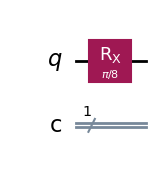

In [80]:
# RX Gate 
theta_x = np.pi/8 # can ask you on EXAM for which angle is the resulting state 
qc_rx = QuantumCircuit(1,1,name ="qc")
#qc_rx.x(0)
qc_rx.rx(theta_x,0)
qc_rx.draw('mpl')


Quantum State is: [0.981+0.j    0.   -0.195j]


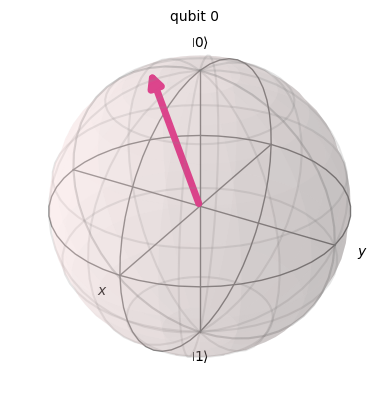

In [81]:
state_R = Statevector.from_instruction(qc_rx)
state_rounded_R = np.round(state_R.data, 3)

print("\nQuantum State is:", state_rounded_R)
plot_bloch_multivector(state_rounded_R)

In [82]:
unitary_R = np.round(Operator(qc_rx).data, 3)   # NumPy array
print(unitary_R)

[[0.981+0.j    0.   -0.195j]
 [0.   -0.195j 0.981+0.j   ]]


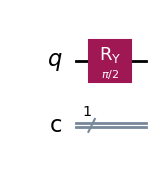

In [83]:
# RY Gate 
theta_y = np.pi/2 # can ask you on EXAM for which angle is the resulting state 
qc_ry = QuantumCircuit(1,1,name ="qc")
#qc_rx.x(0)
qc_ry.ry(theta_y,0)
qc_ry.draw('mpl')


Quantum State is: [0.707+0.j 0.707+0.j]


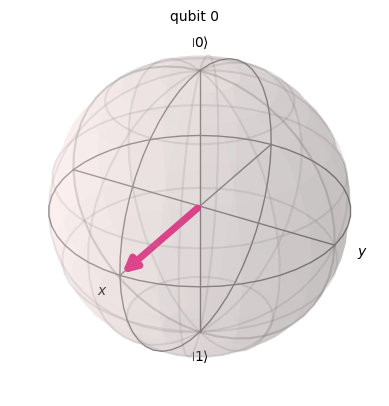

In [84]:
state_Ry = Statevector.from_instruction(qc_ry)
state_rounded_Ry = np.round(state_Ry.data, 3)

print("\nQuantum State is:", state_rounded_Ry)
plot_bloch_multivector(state_rounded_Ry)

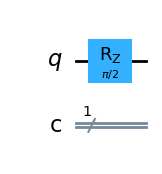

In [85]:
# RZ Gate 
theta_z = np.pi/2 # can ask you on EXAM for which angle is the resulting state 
qc_rz = QuantumCircuit(1,1,name ="qc")
#qc_rz.x(0)
qc_rz.rz(theta_z,0)
qc_rz.draw('mpl')


Quantum State is: [0.707-0.707j 0.   +0.j   ]


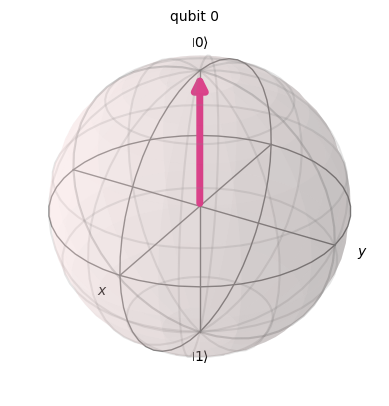

In [86]:
state_Rz = Statevector.from_instruction(qc_rz)
state_rounded_Rz = np.round(state_Rz.data, 3)

print("\nQuantum State is:", state_rounded_Rz)
plot_bloch_multivector(state_rounded_Rz)

In [87]:
unitary_Rz = np.round(Operator(qc_rz).data, 3)   # NumPy array
print(unitary_Rz)

[[0.707-0.707j 0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]


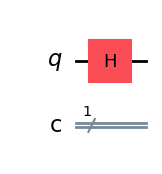

In [88]:
#H Gate
qc_h = QuantumCircuit(1,1,name ="qc")
#qc_h.x(0)
qc_h.h(0)
qc_h.draw('mpl')

In [89]:
unitary_H = np.round(Operator(qc_h).data, 3)   # NumPy array
print(unitary_H)

[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]



Quantum State is: [0.707+0.j 0.707+0.j]


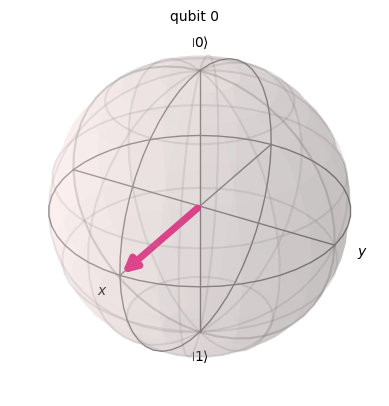

In [90]:
state_H = Statevector.from_instruction(qc_h)
state_rounded_H = np.round(state_H.data, 3)

print("\nQuantum State is:", state_rounded_H)
plot_bloch_multivector(state_rounded_H)

Multi Qubit Qunatum Gates:
------------------------------

In [91]:
#importing nessesary libraries
from qiskit.visualization import plot_state_city # denisty matrix plot
from qiskit.visualization import plot_state_qsphere # used for Multi Qubit Visulaization

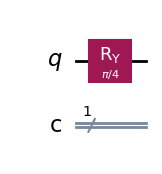

In [103]:
theta_y = np.pi/4 # can ask you on EXAM for which angle is the resulting state 
qc_ry = QuantumCircuit(1,1,name ="qc")
#qc_rz.x(0)
qc_ry.ry(theta_y,0)
qc_ry.draw('mpl')


Quantum State is: [0.924+0.j 0.383+0.j]


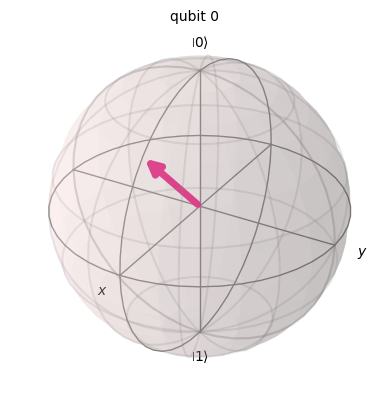

In [104]:
state_Ry = Statevector.from_instruction(qc_ry)
state_rounded_Ry = np.round(state_Ry.data, 3)

print("\nQuantum State is:", state_rounded_Ry)
plot_bloch_multivector(state_rounded_Ry)